# Estruturas de dados - Listas Ligadas
(Parte 3)

## Revisão

Vamos começar com o básico: a representação de uma lista, usando `struct`, `typedef` e ponteiros.

```c
#include<stdio.h>
#include <stdlib.h>

/**
 Vamos usar o prefixo ll para todas as funções que são de Lista Ligada (dois l's)
*/
/* Representação dos dados */
typedef struct no {
    int info;
    struct no * prox;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;

typedef Lista * ListaLigada;
/* --- */
```

Com a nossa representação, fica mais fácil de trabalhar com as listas. Não precisamos mais nos preocupar com ponteiros diretamente, já que uma `Celula` já é um ponteiro para nó, resolvendo nosso problema.

### Criando ListaLigada e Celula

Para usarmos nossa estrutura, precisamos ter funções que consigam criar uma `ListaLigada` e uma `Celula`.

```c
/**
    Cria uma ListaLigada (ponteiro para Lista, que é
    uma estrutura com uma Celula inicio e uma Celula fim
*/
ListaLigada novaLista() {
    ListaLigada l = malloc(sizeof(Lista));
    if (!l) return NULL;
    l->inicio = NULL;
    l->fim = NULL;
    return l;
}
/*
    Cria uma Celula, que é um ponteiro de No, uma
    estrutura contendo um número inteiro info e um
    ponteiro para o próximo no
*/
Celula novaCelula(int info) {
    Celula celula = (Celula) malloc(sizeof(No));
    celula->info = info;
    celula->prox = NULL;

    return celula;
}
```


### Operações de ListaLigada

Vamos definir as operações que queremos ter na nossa `ListaLigada`. O que ela deve ser capaz de fazer?

Para que seja útil, devemos poder:
- Imprimir os dados da lista
- Buscar um valor na lista
- Inserir um valor na lista (começo, fim, antesDe, depoisDe e ordenado)
- Remover um valor da lista (começo, fim, valor x)

Todas as funções receberão uma `ListaLigada` como parâmetro, porque não há outra alternativa no C (a não ser usar uma variável global).

### Imprimir os dados lista

Para fazer um print de todos os valores da lista, precisamos saber como percorrer na lista. Para isso, criamos uma função:
```c
void llPrint(ListaLigada lista) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        printf("%d", aux->info);
        if (aux->prox != NULL)
            printf(" -> ");
    }
    printf("\n");
}
```

### Buscar um valor na lista

```c
/*
    Busca uma Celula a partir de info, retornando seu ponteiro
*/
Celula llBusca(ListaLigada lista, int info) {
    for (Celula aux = lista->inicio; aux != NULL; aux = aux->prox) {
        if (aux->info == info) {
            return aux;
        }
    }
    return NULL;
}
```

### Inserir valores na lista

#### Inserção no início

```c
void llInsereNoInicio(ListaLigada lista, int info) {
    Celula celula = novaCelula(info);
    if (lista->inicio == NULL) { // lista é vazia
        lista->inicio = celula;
        lista->fim = celula;
    }
    else {
        celula->prox = lista->inicio;
        lista->inicio = celula;
    }
}
```

#### Inserção no final

```c
void llInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);
    
    if (lista->inicio == NULL) { // ou seja, a lista está vazia
        lista->inicio = nova;
        lista->fim = nova;
        return;
    }
    lista->fim->prox = nova;
    lista->fim = nova;
}
```


#### Inserção depois de um valor

```c
void llInsereDepoisDe(ListaLigada lista, int alvo, int info) {
    Celula nova = novaCelula(info);
    Celula buscada = llBusca(lista, alvo);
    if (buscada != NULL) { // encontrou!
        nova->prox = buscada->prox;
        buscada->prox = nova;
    }
    else {
        llInsereNoFim(lista, info);
        free(nova);
    }
}
```

#### Inserção antes de um valor

```c
void llInsereAntesDe(ListaLigada lista, int alvo, int info) {
    Celula nova = novaCelula(info);
    Celula aux = NULL;
    for (aux = lista->inicio; aux->prox != NULL && aux->prox->info != alvo; aux = aux->prox);
    if (aux->prox != NULL) { // encontrou!
        nova->prox = aux->prox;
        aux->prox = nova;
    }
    else {
        llInsereNoInicio(lista, info);
        free(nova);
    }
}
```

#### Inserção ordenada

Para realizar inserções ordenadas na nossa lista, podemos pensar em duas etapas distintas:

1. Encontrar o menor elemento que é maior que o elemento que desejamos inserir
2. Inserir antes deste elemento encontrado!

Assim, temos alguns casos:

**Caso 1. Lista vazia**
Nesse caso, é só inserir o elemento.

**Caso 2. Inicio é maior do que o novo elemento**
Se o primeiro item da lista é maior do que o elemento que queremos inserir, basta inserir no início.

**Caso 3. Fim é menor do que o novo elemento**
Ou seja, o último elemento da lista é menor do que o que queremos inserir. Basta inserir no fim. 

**Caso 4. Precisamos buscar onde inserir**
Precisamos encontrar onde está o menor elemento que é maior que o elemento que desejamos inserir.

Para verificar se a lista está vazia:
```c
lista->inicio == NULL
```

Para verificar se o primeiro item é maior que o novo elemento `novo`
```c
lista->inicio->info > novo
```

Assim, conseguimos criar a função!

```c
void llInsereOrdenado(ListaLigada lista, int info) {
    if (lista == NULL) return; // lista inexiste
    
    // Casos 1 e 2; nos dois, inserimos no início
    if (lista->inicio == NULL || lista->inicio->info > info) {
        llInsereNoInicio(lista, info);
    }
    // Caso 3
    else if (lista->fim->info < info) {
        llInsereNoFim(lista, info);
    }
    // Caso 4
    else {
        Celula nova = novaCelula(info);
        Celula aux = lista->inicio;
        // Anda na lista atualizando aux, até que eu encontre o elemento que aponta para
        // o menor valor anterior ao novo info a ser inserido
        while(aux->prox != NULL && aux->prox->info <= info) {
            aux = aux->prox;
        }
        nova->prox = aux->prox;
        aux->prox = nova;
    }
}
```

### Remoção

#### No início

```c
void llRemoveInicio(ListaLigada lista) {
    if (lista->inicio == NULL) {
        return;
    }

    Celula removido = lista->inicio;
    lista->inicio = removido->prox;

    if (lista->inicio == NULL) {
        lista->fim = NULL;
    }

    free(removido);
}
```

#### No fim

```c
Celula llGetPenultimo(ListaLigada lista) {
    if (lista->inicio == NULL) {
        return NULL;
    }

    Celula penultimo = NULL;
    for(Celula aux = lista->inicio; aux->prox != NULL; aux = aux->prox) {
        penultimo = aux;
    }
    return penultimo;
}

void llRemoveFim(ListaLigada lista) {
    Celula penultimo = llGetPenultimo(lista);
    Celula removido = lista->fim;
    lista->fim = penultimo;
    penultimo->prox = NULL;
    free(removido);
}
```

#### Um alvo

```c
/*
    Remove uma Celula específica da Lista, baseado em seu valor info.
    Remove a primeira ocorrência de 'alvo'.
*/
void llRemove(ListaLigada lista, int alvo) {
    if (lista == NULL || lista->inicio == NULL) {
        return; // lista inexistente ou vazia
    }

    // Caso 1: o alvo é o primeiro nó
    if (lista->inicio->info == alvo) {
        Celula removido = lista->inicio;
        lista->inicio = removido->prox;

        // se removeu o único elemento da lista
        if (lista->inicio == NULL) {
            lista->fim = NULL;
        }

        free(removido); // libera a memória
        return;
    }

    // Caso 2: procurar nó anterior ao que será removido
    Celula aux;
    // Este for faz com que o aux seja atualizado até encontrar o elemento anterior ao alvo!
    for (aux = lista->inicio; aux->prox != NULL && aux->prox->info != alvo; aux = aux->prox);

    // Se encontrou o alvo
    if (aux->prox != NULL) {
        Celula removido = aux->prox;
        aux->prox = removido->prox;

        // se removeu o último nó, atualiza o fim
        if (removido == lista->fim) {
            lista->fim = aux;
        }

        free(removido); // libera a memória
    }
}
```

## Listas duplamente ligadas

Na remoção de elementos no fim da lista como estruturamos, temos um problema: precisamos percorrer a lista até encontrar o penúltimo elemento (por isso criamos a função `llGetPenultimo`). Ao realizar uma análise deste algoritmo, percebemos que ele é `O(n)`, já que no pior caso vai percorrer todos os elementos da lista até encontrar o que precisa ser removido, uma vez que precisa atualizar os ponteiros do final da lista.

Para este problema ser resolvido de maneira eficiente, podemos utilizar uma nova estrutura: a lista duplamente ligada. É o mesmo conceito da `ListaLigada`, mas com uma modificação: agora temos um ponteiro para o elemento anterior, além do ponteiro `prox`.

A estrutura fica assim:

```c
#include <stdio.h>
#include <stdlib.h>

typedef struct no {
    int info;
    struct no *prox;
    struct no *prev;
} No;

typedef No * Celula;

typedef struct lista {
    Celula inicio;
    Celula fim;
} Lista;

typedef Lista * ListaDuplamenteLigada;
```

### Remoção no fim

Então como fica a remoção no final da lista duplamente ligada? Agora temos o ponteiro do valor anterior ao último, por isso não precisamos mais percorrer a lista buscando o penúltimo elemento!

Nosso algoritmo agora muda e fica muito mais eficiente. Mas nem tudo são rosas, ao mesmo tempo agora temos mais um ponteiro na estrutura e as operações de inserção e remoção no geral precisam atualizar mais ponteiros.

#### algoritmo

```c
void lldRemoveNoFim(ListaDuplamenteLigada lista) {
    if (lista == NULL || lista->fim == NULL) {
        return; // lista inexistente ou vazia
    }

    Celula removido = lista->fim;

    // Caso 1: só existe um elemento
    if (lista->inicio == lista->fim) {
        lista->inicio = NULL;
        lista->fim = NULL;
    }
    // Caso 2: há mais de um elemento
    else {
        lista->fim = removido->ant;
        lista->fim->prox = NULL;
    }

    free(removido);
}
```

## Lista Circular

Existe um tipo especial de lista ligada: a lista circular.

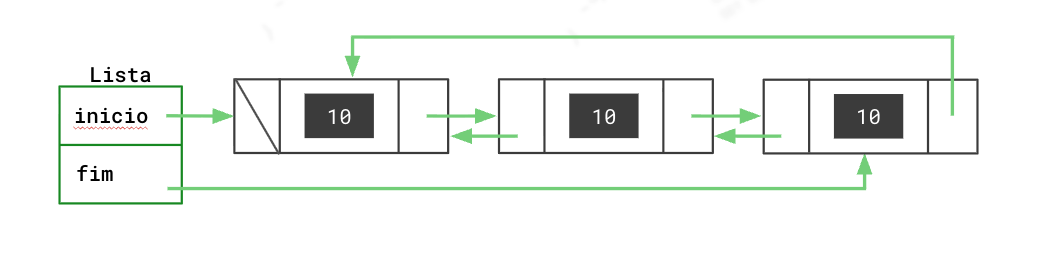

Basicamente o último elemento aponta para o primeiro, fazendo com que a lista nunca "acabe" de fato.

Para usar uma lista circular, algumas operações precisam sofrer modificações. São elas:

1. Inserção no início: o último elemento precisa continuar apontando para o novo início
2. Inserção no fim: o novo último elemento deve apontar para o início
3. Remoção no início: o último elemento precisa continuar apontando para o novo primeiro
4. Percorrer a lista: temos que tomar cuidado com a condição de parada do loop

### Inserção no fim

```c
void lcInsereNoFim(ListaLigada lista, int info) {
    Celula nova = novaCelula(info);

    if (lista->inicio == NULL) {
        lista->inicio = nova;
        lista->fim = nova;
        nova->prox = nova; // aponta para si mesma
    }
    else {
        nova->prox = lista->inicio;
        lista->fim->prox = nova;
        lista->fim = nova;
    }
}
```

### Percorrendo a lista

Agora não podemos mais utilizar a condição `aux != NULL`, porque `aux` nunca assumirá `NULL` em uma lista não vazia - será sempre algum valor válido.

Tomando esse cuidado, temos que criar um algoritmo que verifique se `aux` é diferente do início da lista.

```c
void lcPrint(ListaLigada lista) {
    if (lista->inicio == NULL)
        return;

    Celula aux = lista->inicio;
    do {
        printf("%d ", aux->info);
        aux = aux->prox;
    }
    while(aux != lista->inicio);
    printf("\n");
}
```